<a href="https://colab.research.google.com/github/Reyansh657/chronic-kidney-disease-model/blob/main/chronic_kidney_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

kidney = fetch_ucirepo(id=336)

X = kidney.data.features
y = kidney.data.targets["class"]

print(X.shape)
print(y.value_counts())

(400, 24)
class
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [4]:
X = X[[
    "age",
    "bp",
    "bgr",
    "bu",
    "sc",
    "hemo"
]]
print(X.columns)

Index(['age', 'bp', 'bgr', 'bu', 'sc', 'hemo'], dtype='object')


In [5]:
X.head()

,age,bp,bgr,bu,sc,hemo
0,48.0,80.0,121.0,36.0,1.2,15.4
1,7.0,50.0,NaN,18.0,0.8,11.3
2,62.0,80.0,423.0,53.0,1.8,9.6
3,48.0,70.0,117.0,56.0,3.8,11.2
4,51.0,80.0,106.0,26.0,1.4,11.6


In [6]:
y = y.astype(str)
y = y.str.strip()
print(y.value_counts())

class
ckd       250
notckd    150
Name: count, dtype: int64


In [7]:
print(X.isnull().sum())

age      9
bp      12
bgr     44
bu      19
sc      17
hemo    52
dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2067,
    stratify=y
)
print("training:", len(X_train))
print("testing:", len(X_test))

training: 320
testing: 80


In [9]:
middle = X_train.median()
X_train = X_train.fillna(middle)
X_test = X_test.fillna(middle)
print(X_train.isnull().sum())

age     0
bp      0
bgr     0
bu      0
sc      0
hemo    0
dtype: int64


In [10]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=100,
    random_state=2026
)

In [11]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5
)
print(scores)
print("average:", round(scores.mean() * 100, 2), "percent")

[0.96875  0.953125 0.96875  1.       0.984375]
average: 97.5 percent


In [12]:
tree_numbers =[50, 100, 200]
for trees in tree_numbers:
  test_model = RandomForestClassifier(
      n_estimators=trees,
      random_state=67
  )
  scores = cross_val_score(
      test_model,
      X_train,
      y_train,
      cv=5
  )
  print("trees:", trees)
  print("sroce:", round(scores.mean() * 100, 2), "percent")

trees: 50
sroce: 97.5 percent
trees: 100
sroce: 97.5 percent
trees: 200
sroce: 97.5 percent


In [13]:
best_trees = 50
print(best_trees)

50


In [14]:
model = RandomForestClassifier(
    n_estimators=best_trees,
    random_state=200
)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, random_state=200)

In [15]:
predictions = model.predict(X_test)
print(predictions)

['notckd' 'notckd' 'ckd' 'ckd' 'ckd' 'ckd' 'ckd' 'ckd' 'notckd' 'ckd'
 'ckd' 'ckd' 'notckd' 'ckd' 'notckd' 'ckd' 'notckd' 'ckd' 'ckd' 'ckd'
 'ckd' 'notckd' 'ckd' 'ckd' 'notckd' 'ckd' 'ckd' 'ckd' 'notckd' 'notckd'
 'notckd' 'ckd' 'notckd' 'notckd' 'notckd' 'notckd' 'ckd' 'ckd' 'ckd'
 'ckd' 'notckd' 'notckd' 'ckd' 'ckd' 'notckd' 'ckd' 'ckd' 'ckd' 'ckd'
 'ckd' 'notckd' 'notckd' 'ckd' 'notckd' 'ckd' 'notckd' 'ckd' 'notckd'
 'notckd' 'notckd' 'notckd' 'ckd' 'ckd' 'ckd' 'ckd' 'ckd' 'notckd' 'ckd'
 'ckd' 'ckd' 'ckd' 'notckd' 'notckd' 'ckd' 'ckd' 'ckd' 'ckd' 'notckd'
 'ckd' 'ckd']


In [16]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print("accuracy:", round(accuracy * 100, 2), "percent")

accuracy: 95.0 percent


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         ckd       0.96      0.96      0.96        50
      notckd       0.93      0.93      0.93        30

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



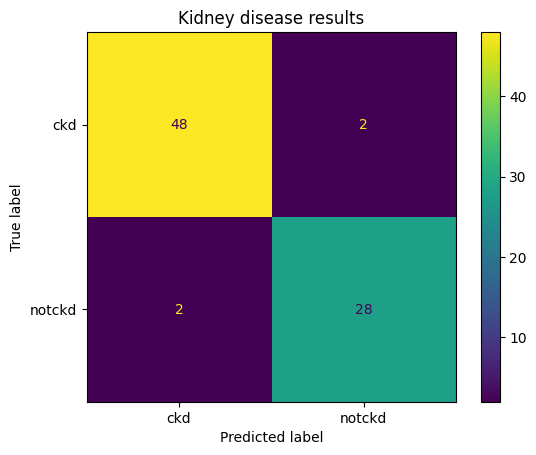

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)
plt.title("Kidney disease results")
plt.show()

In [19]:
one_patient = X_test[0:1]
guess = model.predict(one_patient)
print("orediction:", guess[0])

orediction: notckd


In [20]:
chances = model.predict_proba(one_patient)
print(model.classes_)
print(chances)

['ckd' 'notckd']
[[0.1 0.9]]


In [21]:
import ipywidgets as widgets
from IPython.display import display

box_style = {"description_width": "130px"}
box_size = widgets.Layout(width="350px")
age_box = widgets.FloatText(
    description="Age:",
    style=box_style,
    layout=box_size
)
bp_box = widgets.FloatText(
    description="Blood Pressure:",
    style=box_style,
    layout=box_size
)
bgr_box = widgets.FloatText(
    description="Blood Glucose:",
    style=box_style,
    layout=box_size
)

bu_box = widgets.FloatText(
    description="Blood urea:",
    style=box_style,
    layout=box_size
)
sc_box = widgets.FloatText(
    description="Creatinine:",
    style=box_style,
    layout=box_size

)
hemo_box = widgets.FloatText(
    description="Hemoglobin",
    style=box_style,
    layout=box_size
)

check_button = widgets.Button(
    description="check patient"
)






result_box = widgets.Output()

In [22]:
def check_patient(button):
  new_patient = pd.DataFrame({
      "age": [age_box.value],
      "bp": [bp_box.value],
      "bgr": [bgr_box.value],
      "bu": [bu_box.value],
      "sc": [sc_box.value],
      "hemo": [hemo_box.value]
  })
  guess = model.predict(new_patient)
  chances = model.predict_proba(new_patient)

  with result_box:
    result_box.clear_output()
    print("model prediction:", guess[0])

    for i in range(len(model.classes_)):
      percent = chances[0][i] * 100
      print(
          model.classes_[i],
          ":",
          round(percent, 2),
          "%"
      )

In [23]:
check_button.on_click(check_patient)
print("kidney Disease Prediction Project")
print("Please enter the patients information below")
display(age_box)
display(bp_box)
display(bgr_box)
display(bu_box)
display(sc_box)
display(hemo_box)
display(check_button)
display(result_box)

kidney Disease Prediction Project
Please enter the patients information below


FloatText(value=0.0, description='Age:', layout=Layout(width='350px'), style=DescriptionStyle(description_widt…

FloatText(value=0.0, description='Blood Pressure:', layout=Layout(width='350px'), style=DescriptionStyle(descr…

FloatText(value=0.0, description='Blood Glucose:', layout=Layout(width='350px'), style=DescriptionStyle(descri…

FloatText(value=0.0, description='Blood urea:', layout=Layout(width='350px'), style=DescriptionStyle(descripti…

FloatText(value=0.0, description='Creatinine:', layout=Layout(width='350px'), style=DescriptionStyle(descripti…

FloatText(value=0.0, description='Hemoglobin', layout=Layout(width='350px'), style=DescriptionStyle(descriptio…

Button(description='check patient', style=ButtonStyle())

Output()

In [25]:
ckd_chances = model.predict_proba(X_test)[:, 0]

sure_ckd = X_test[ckd_chances == 1.0]

print(sure_ckd[0:1])

     age    bp    bgr    bu   sc  hemo
35  65.0  90.0  270.0  39.0  2.0  12.0
